# Optimized Hybrid Model: PhoBERT + SentiWordNet (Fine-tuned + Positional Encoding + SiLU)

## Key Optimizations:
1. **Gradual unfreezing** - PhoBERT layers are gradually unfrozen (frozen -> partial -> full)
2. **Computed class weights** - Uses sklearn's balanced class weights instead of fixed values
3. **Discriminative learning rates** - Different LR for PhoBERT vs classifier head
4. **Positional encoding** - Adds sinusoidal positional encoding on PhoBERT token embeddings before pooling
5. **SiLU activations** - Replaces `nn.ReLU` with `nn.SiLU` in projection and classifier layers
6. **Better fusion architecture** - LayerNorm after concatenation for improved feature fusion
7. **Extended SentiWordNet Features** - 35 features including negation, position, and statistical features
8. **Macro-F1 selection** - Uses macro-F1 for model selection with Neutral class monitoring


## 1. Setup và Import Libraries

In [12]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [13]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score, precision_recall_fscore_support
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from tqdm import tqdm
from IPython.display import display
from src.data_utils import (
    load_data, load_sentiwordnet, preprocess_vietnamese,
    extract_swn_features_extended_batch, SWN_EXTENDED_FEATURE_NAMES
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [14]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    SENTIWORDNET_FILE = os.path.join(BASE_DIR, 'data', 'sentiwordnet-dataset', 'VietSentiWordnet_Ver1.3.5.txt')

    MODEL_TYPE = 'PhoBERT_Sentiwordnet_Optimized_PosEnc_SiLU'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 32
    EPOCHS = 10
    EARLY_STOP_PATIENCE = 3
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    # Gradual unfreezing schedule
    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 5e-5

    # Unfreezing epochs
    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4

    # Architecture
    SWN_PROJ_DIM = 64
    CLASSIFIER_HIDDEN_DIM = 256

    # Selection metric
    SELECTION_METRIC = 'f1_macro'

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

print('='*60)
print('OPTIMIZED CONFIGURATION')
print('='*60)
print(f'Model: {config.MODEL_NAME}')
print(f'SentiWordNet Features: 35 (extended)')
print('Positional Encoding: enabled')
print(f'Freeze Epochs: {config.FREEZE_EPOCHS}')
print('Activation: SiLU')
print(f'Batch Size: {config.BATCH_SIZE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Selection Metric: {config.SELECTION_METRIC}')
print(f'Gradual Unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH-1}, full@{config.FULL_UNFREEZE_EPOCH}+')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')


OPTIMIZED CONFIGURATION
Model: vinai/phobert-base
SentiWordNet Features: 35 (extended)
Positional Encoding: enabled
Freeze Epochs: 1
Activation: SiLU
Batch Size: 32
Epochs: 10
Selection Metric: f1_macro
Gradual Unfreezing: freeze<2, partial@2-3, full@4+
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet_Optimized_PosEnc_SiLU/improvements/20260319_052834


## 3. Load Data

In [15]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. Load SentiWordNet & Extract Extended Features

In [16]:
# Load VietSentiWordNet lexicon
print('Loading VietSentiWordNet lexicon...')
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
print(f'Loaded {len(word_to_scores)} words')

# Extract extended features (35 features)
print('\nExtracting Extended SentiWordNet features (35 features)...')
train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores)
val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores)
test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores)

print(f'SentiWordNet features shape: Train={train_swn.shape}, Val={val_swn.shape}, Test={test_swn.shape}')

# Scale features
swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn).astype(np.float32)
val_swn_scaled = swn_scaler.transform(val_swn).astype(np.float32)
test_swn_scaled = swn_scaler.transform(test_swn).astype(np.float32)

joblib.dump(swn_scaler, os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'))
print('SentiWordNet scaler saved.')

Loading VietSentiWordNet lexicon...
Loaded 1227 words

Extracting Extended SentiWordNet features (35 features)...
SentiWordNet features shape: Train=(11426, 35), Val=(1583, 35), Test=(3166, 35)
SentiWordNet scaler saved.


## 5. Model Definition - Optimized Hybrid

In [17]:
class HybridDataset(Dataset):
    """Dataset that returns text + SentiWordNet features + labels"""
    def __init__(self, texts, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'swn_features': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [18]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * (-torch.log(torch.tensor(10000.0)) / d_model)
        )
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        seq_len = x.size(1)
        return self.dropout(x + self.pe[:, :seq_len, :].to(dtype=x.dtype))


class PhoBertSentiWordNetOptimizedPositional(nn.Module):
    """Optimized Hybrid model: PhoBERT + SentiWordNet with external positional encoding."""
    def __init__(self, model_name, num_classes, swn_dim=35, dropout=0.3):
        super().__init__()

        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_hidden_size = self.phobert.config.hidden_size
        max_pos = max(getattr(self.phobert.config, 'max_position_embeddings', config.MAX_LENGTH), config.MAX_LENGTH)
        self.positional_encoding = PositionalEncoding(phobert_hidden_size, max_pos, dropout)

        self.swn_projection = nn.Sequential(
            nn.Linear(swn_dim, config.SWN_PROJ_DIM),
            nn.LayerNorm(config.SWN_PROJ_DIM),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

        combined_size = phobert_hidden_size + config.SWN_PROJ_DIM
        self.fusion_norm = nn.LayerNorm(combined_size)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_size, config.CLASSIFIER_HIDDEN_DIM),
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def forward(self, input_ids, attention_mask, swn_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = self.positional_encoding(outputs.last_hidden_state)
        mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
        pooled_output = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        swn_projected = self.swn_projection(swn_features)
        combined = torch.cat([pooled_output, swn_projected], dim=1)
        combined = self.fusion_norm(combined)

        logits = self.classifier(combined)
        return logits


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Initialize tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBertSentiWordNetOptimizedPositional(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    swn_dim=35,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 135,216,899
Initial trainable parameters: 135,216,899


## 6. Create DataLoaders

In [19]:
train_dataset = HybridDataset(train_texts, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 358
Val batches: 50
Test batches: 99


## 7. Training Setup with Gradual Unfreezing

In [20]:
# Compute class weights from data (FIX: use balanced weights, not fixed [1, 5, 1])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=np.array(train_labels)
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Class weights (computed from data): {class_weights.tolist()}')


def get_training_stage(epoch_number):
    """Determine training stage based on epoch number."""
    if epoch_number <= config.FREEZE_EPOCHS:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'


def set_phobert_trainable_layers(model, stage):
    """Set PhoBERT layers trainable based on training stage."""
    # First freeze all PhoBERT parameters
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        # Unfreeze last N encoder layers
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        # Unfreeze all PhoBERT parameters
        for param in model.phobert.parameters():
            param.requires_grad = True

    # Always keep projection and classifier trainable
    for module in [model.swn_projection, model.fusion_norm, model.classifier]:
        for param in module.parameters():
            param.requires_grad = True


def build_optimizer_and_scheduler(model, stage, epoch_number):
    """Build optimizer with discriminative learning rates."""
    phobert_lr = {
        'frozen': config.PHOBERT_LR_FROZEN,
        'partial': config.PHOBERT_LR_PARTIAL,
        'full': config.PHOBERT_LR_FULL
    }[stage]

    optimizer_groups = []

    # PhoBERT parameters (if trainable)
    phobert_params = [p for p in model.phobert.parameters() if p.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})

    # Head parameters (always trainable with higher LR)
    head_params = [p for module in [model.swn_projection, model.fusion_norm, model.classifier] for p in module.parameters() if p.requires_grad]
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})

    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)

    # Calculate remaining steps for scheduler
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps


# Initial setup - freeze PhoBERT
set_phobert_trainable_layers(model, 'frozen')
print(f'Trainable params after freeze: {count_trainable_params(model):,}')


Class weights (computed from data): [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze: 218,627


## 8. Training Loop

In [21]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        swn_features = batch['swn_features'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, swn_features)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1_macro


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            swn_features = batch['swn_features'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, swn_features)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)

    # Per-class metrics
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }

In [22]:
# Training loop
history = {
    'epoch': [], 'stage': [],
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_neutral': [],
    'phobert_lr': [], 'trainable_params': []
}

best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('='*70)
print('START TRAINING WITH GRADUAL UNFREEZING')
print('='*70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)

    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')

    print(f'\nEpoch {epoch}/{config.EPOCHS}')

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_neutral'].append(val_metrics['f1_per_class'][1])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))

    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")

    # Model selection based on MACRO F1
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> New best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)

print(f'\nBest epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')

START TRAINING WITH GRADUAL UNFREEZING

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=218,627

Epoch 1/10


Train  - loss=1.0574 acc=0.5038 f1_macro=0.3952
Val    - loss=0.9079 acc=0.6702 f1_macro=0.5492 f1_neutral=0.2593
  -> New best model saved (val macro F1=0.5492)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=28,570,115

Epoch 2/10


Train  - loss=0.8547 acc=0.6945 f1_macro=0.5564
Val    - loss=0.5864 acc=0.8686 f1_macro=0.7160 f1_neutral=0.3478
  -> New best model saved (val macro F1=0.7160)

Epoch 3/10


Train  - loss=0.5438 acc=0.8539 f1_macro=0.7013
Val    - loss=0.4807 acc=0.8825 f1_macro=0.7594 f1_neutral=0.4435
  -> New best model saved (val macro F1=0.7594)

[Stage Switch] epoch=4 stage=full phobert_lr=2e-05 trainable_params=135,216,899

Epoch 4/10


Train  - loss=0.4476 acc=0.8839 f1_macro=0.7483
Val    - loss=0.5909 acc=0.9330 f1_macro=0.8239 f1_neutral=0.5735
  -> New best model saved (val macro F1=0.8239)

Epoch 5/10


Train  - loss=0.3629 acc=0.9291 f1_macro=0.8280
Val    - loss=0.5552 acc=0.9343 f1_macro=0.8404 f1_neutral=0.6241
  -> New best model saved (val macro F1=0.8404)

Epoch 6/10


Train  - loss=0.2657 acc=0.9524 f1_macro=0.8852
Val    - loss=0.6168 acc=0.9419 f1_macro=0.8507 f1_neutral=0.6395
  -> New best model saved (val macro F1=0.8507)

Epoch 7/10


Train  - loss=0.2000 acc=0.9655 f1_macro=0.9178
Val    - loss=0.8448 acc=0.9413 f1_macro=0.8404 f1_neutral=0.6107
  -> No improvement, patience=1/3

Epoch 8/10


Train  - loss=0.1374 acc=0.9774 f1_macro=0.9503
Val    - loss=0.8316 acc=0.9375 f1_macro=0.8371 f1_neutral=0.6040
  -> No improvement, patience=2/3

Epoch 9/10


Train  - loss=0.1006 acc=0.9823 f1_macro=0.9595
Val    - loss=0.9906 acc=0.9419 f1_macro=0.8402 f1_neutral=0.6094
  -> No improvement, patience=3/3
  -> Early stopping at epoch 9

Best epoch: 6, best stage: full, best val macro F1: 0.8507


## 9. Evaluation on Test Set

In [23]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation Classification Report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

print('\nTest Classification Report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

Validation Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95       705
     Neutral       0.64      0.64      0.64        73
    Positive       0.97      0.96      0.96       805

    accuracy                           0.94      1583
   macro avg       0.85      0.85      0.85      1583
weighted avg       0.94      0.94      0.94      1583


Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94      1409
     Neutral       0.58      0.63      0.60       167
    Positive       0.95      0.94      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.82      0.84      0.83      3166
weighted avg       0.93      0.93      0.93      3166



## 10. Save Results

In [24]:
# Summary dataframe
summary_df = pd.DataFrame([
    {
        'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'],
        'F1_Weighted': val_results['f1_weighted'],
        'F1_Negative': val_results['f1_per_class'][0],
        'F1_Neutral': val_results['f1_per_class'][1],
        'F1_Positive': val_results['f1_per_class'][2]
    },
    {
        'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'],
        'F1_Weighted': test_results['f1_weighted'],
        'F1_Negative': test_results['f1_per_class'][0],
        'F1_Neutral': test_results['f1_per_class'][1],
        'F1_Positive': test_results['f1_per_class'][2]
    },
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

experiment_summary = {
    'model_type': config.MODEL_TYPE,
    'experiment_type': config.EXPERIMENT_TYPE,
    'timestamp': config.TIMESTAMP,
    'epochs_configured': config.EPOCHS,
    'best_epoch': best_epoch,
    'best_stage': best_stage,
    'selection_metric': config.SELECTION_METRIC,
    'best_val_f1_macro': best_val_f1,
    'unfreezing_schedule': {
        'freeze_epochs': list(range(1, config.FREEZE_EPOCHS + 1)),
        'partial_unfreeze_start_epoch': config.PARTIAL_UNFREEZE_EPOCH,
        'partial_unfreeze_last_n_layers': config.PARTIAL_UNFREEZE_LAST_N,
        'full_unfreeze_start_epoch': config.FULL_UNFREEZE_EPOCH
    },
    'validation': val_results,
    'test': test_results,
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

# Training results text
with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('='*60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + SentiWordNet (OPTIMIZED + Positional Encoding + SiLU)\n')
    f.write('='*60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f'Test Accuracy: {test_results["accuracy"]:.4f}\n')
    f.write(f'Test F1 Macro: {test_results["f1_macro"]:.4f}\n')
    f.write(f'Test F1 Weighted: {test_results["f1_weighted"]:.4f}\n')
    f.write(f'Test F1 Neutral: {test_results["f1_per_class"][1]:.4f}\n')

print(f'Saved outputs to: {config.RESULTS_DIR}')


,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,6,full,0.941883,0.850717,0.942006,0.952045,0.639456,0.960650
1,Test,6,full,0.926406,0.831224,0.927168,0.943757,0.603448,0.946468


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet_Optimized_PosEnc_SiLU/improvements/20260319_052834


## 11. Visualization

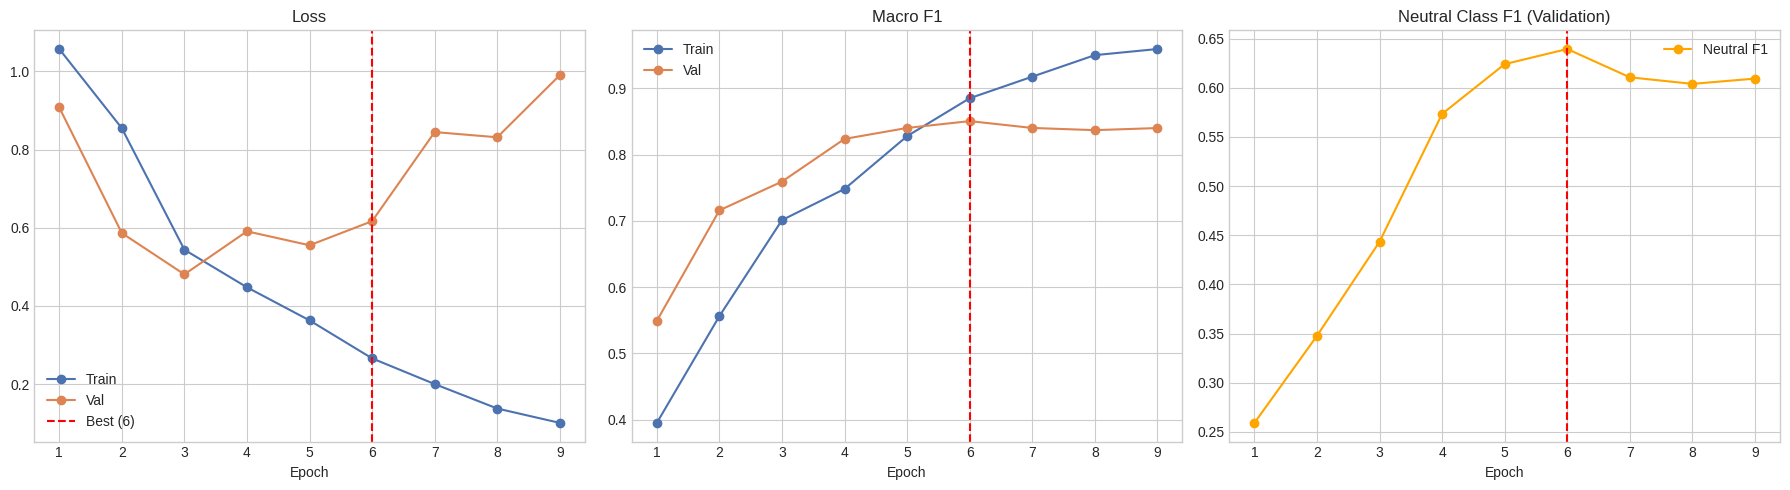

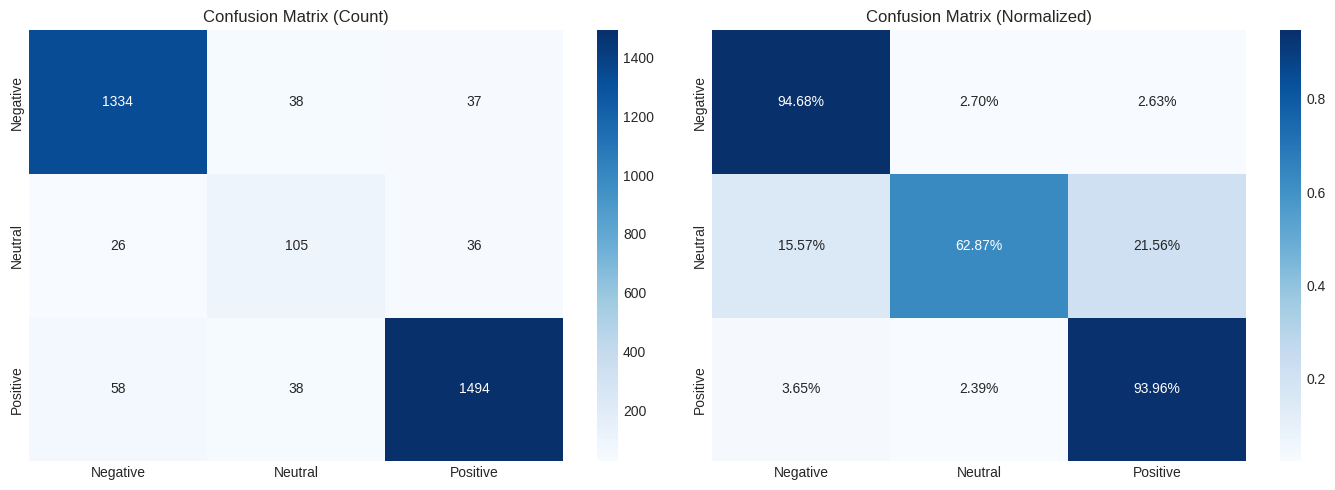

In [25]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--')
axes[1].set_title('Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_f1_neutral'], marker='o', color='orange', label='Neutral F1')
axes[2].axvline(best_epoch, color='red', linestyle='--')
axes[2].set_title('Neutral Class F1 (Validation)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Error Analysis for Neutral Class

In [26]:
# Find misclassified Neutral samples
neutral_indices = [i for i, label in enumerate(test_results['y_true']) if label == 1]
misclassified_neutral = [
    (i, test_results['y_pred'][i], test_texts[i])
    for i in neutral_indices
    if test_results['y_pred'][i] != 1
]

print(f'Total Neutral samples: {len(neutral_indices)}')
print(f'Misclassified Neutral: {len(misclassified_neutral)}')
print(f'Neutral accuracy: {1 - len(misclassified_neutral)/len(neutral_indices):.2%}')

print('\n--- Sample Misclassified Neutral Feedback ---')
for idx, pred, text in misclassified_neutral[:10]:
    pred_label = config.LABEL_MAP[pred]
    print(f'  Predicted: {pred_label} | Text: "{text[:80]}..."' if len(text) > 80 else f'  Predicted: {pred_label} | Text: "{text}"')

# Count which classes Neutral is confused with
confusion_targets = Counter([pred for _, pred, _ in misclassified_neutral])
print(f'\nNeutral confusion targets:')
for cls, count in sorted(confusion_targets.items()):
    print(f'  {config.LABEL_MAP[cls]}: {count}')

Total Neutral samples: 167
Misclassified Neutral: 62
Neutral accuracy: 62.87%

--- Sample Misclassified Neutral Feedback ---
  Predicted: Positive | Text: "môn học này giúp chúng em hiểu ra những vấn đề cơ bản"
  Predicted: Positive | Text: "như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết"
  Predicted: Positive | Text: "ví dụ phù hợp với nội dung kiến thức hướng dẫn chị tiết"
  Predicted: Positive | Text: "kỹ những chương cuối"
  Predicted: Positive | Text: "có kết hợp với bài tập ví dụ"
  Predicted: Positive | Text: "có cung cấp tài liệu cho sinh viên"
  Predicted: Positive | Text: "ngoài ra còn nhiều kiến thức ngoài"
  Predicted: Negative | Text: "cách tính điểm cộng của giáo viên có điểm quá trình"
  Predicted: Negative | Text: "em nghĩ như vậy sẽ tốt hơn vì họ sẽ biết được khả năng của sinh viên trong lớp t..."
  Predicted: Positive | Text: "đảm bảo cho sinh viên không ngủ gật"

Neutral confusion targets:
  Negative: 26
  Positive: 36


## 13. Final Summary

In [27]:
print('='*70)
print('OPTIMIZED PHOBERT + SENTIWORDNET + POSITIONAL ENCODING + SILU - FINAL SUMMARY')
print('='*70)

print('\nKey Optimizations Applied:')
print('  1. Gradual unfreezing: frozen -> partial -> full')
print('  2. Computed class weights from data (not fixed [1, 5, 1])')
print('  3. Discriminative learning rates')
print('  4. Positional encoding on PhoBERT token embeddings before pooling')
print('  5. SiLU activations in projection and classifier layers')
print('  6. LayerNorm after concatenation for better fusion')
print('  7. Extended SentiWordNet features')
print('  8. Macro-F1 for model selection')

print(f'\nBest epoch: {best_epoch}')
print(f'Best stage: {best_stage}')
print(f'Best val macro F1: {best_val_f1:.4f}')

print(f'\nTest Results:')
print(f'  Accuracy: {test_results["accuracy"]:.4f}')
print(f'  F1 Macro: {test_results["f1_macro"]:.4f}')
print(f'  F1 Weighted: {test_results["f1_weighted"]:.4f}')

print('\nPer-Class F1:')
for i, name in config.LABEL_MAP.items():
    print(f'  {name}: {test_results["f1_per_class"][i]:.4f}')

print('\n' + '='*70)


OPTIMIZED PHOBERT + SENTIWORDNET + POSITIONAL ENCODING + SILU - FINAL SUMMARY

Key Optimizations Applied:
  1. Gradual unfreezing: frozen -> partial -> full
  2. Computed class weights from data (not fixed [1, 5, 1])
  3. Discriminative learning rates
  4. Positional encoding on PhoBERT token embeddings before pooling
  5. SiLU activations in projection and classifier layers
  6. LayerNorm after concatenation for better fusion
  7. Extended SentiWordNet features
  8. Macro-F1 for model selection

Best epoch: 6
Best stage: full
Best val macro F1: 0.8507

Test Results:
  Accuracy: 0.9264
  F1 Macro: 0.8312
  F1 Weighted: 0.9272

Per-Class F1:
  Negative: 0.9438
  Neutral: 0.6034
  Positive: 0.9465

